# Lab 3 (OPT-1) — Gradient Descent, Step Size Stability, Armijo Line Search

**Course:** Mathematical Foundations of Machine and Deep Learning
**Format:** 1.5h guided lab (Colab/Jupyter)
**Allowed libs:** numpy, matplotlib (seaborn optional)

**Content description (what we’ll do):**
In this lab, you implement gradient descent (GD) from scratch and explore how the learning rate controls stability and convergence speed.
You compare convex and non-convex objectives using iteration histories and visualizations.
Next, you implement Armijo backtracking line search to adapt step sizes automatically and observe improved stability.


## Learning objectives (you should be able to...)
1. Implement gradient descent in 1D and 2D and return a history of iterates.
2. Explain (visually + intuitively) why too-large learning rates cause oscillation/divergence.
3. Compare convex vs non-convex behavior: sensitivity to learning rate and initialization.
4. Implement Armijo backtracking and interpret the step-size sequence η_k.

## Minute-by-minute plan (10 / 80)
**Intro (10 min)**
- GD update rule + intuition (convex vs non-convex)
- Step size stability
- Why line search helps

**Hands-on (80 min)**
- Module 1 : 1D GD from scratch + learning rate sweep
- Module 2 : Armijo backtracking line search (1D)
- Module 3 : Incorporate Numerical Methods for ODEs
- Module 4 : Stochastic Gradient Descent (SGD)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# (Optional) seaborn is allowed, but not required.
# import seaborn as sns

np.set_printoptions(precision=4, suppress=True)

# For reproducibility in any random choices we might add later
rng = np.random.default_rng(0)


In [6]:
def plot_1d_function_with_path(f, xs, history, title="", num_points=400):
    """
    Plot f(x) over [min(xs), max(xs)] and overlay GD iterates.
    history: array-like of x_k
    """
    x_grid = np.linspace(xs[0], xs[1], num_points)
    y_grid = np.array([f(x) for x in x_grid])

    plt.figure(figsize=(7, 4))
    plt.plot(x_grid, y_grid, linewidth=2)
    hk = np.array(history, dtype=float)
    plt.scatter(hk, [f(x) for x in hk], s=35)
    plt.plot(hk, [f(x) for x in hk], linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_history(history, f, title_prefix=""):
    """
    Two plots:
    - x_k vs k
    - f(x_k) vs k
    """
    hk = np.array(history, dtype=float)
    fk = np.array([f(x) for x in hk])

    plt.figure(figsize=(7, 3.5))
    plt.plot(hk, marker="o")
    plt.title(f"{title_prefix} x_k vs iteration")
    plt.xlabel("k")
    plt.ylabel("x_k")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3.5))
    plt.plot(fk, marker="o")
    plt.title(f"{title_prefix} f(x_k) vs iteration")
    plt.xlabel("k")
    plt.ylabel("f(x_k)")
    plt.grid(True, alpha=0.3)
    plt.show()


def contour_with_trajectory(f, traj, xlim=(-5, 5), ylim=(-5, 5), levels=30, title=""):
    """
    Contour plot of f(x,y) with a trajectory overlay.
    traj: array-like shape (T, 2)
    """
    traj = np.array(traj, dtype=float)
    xs = np.linspace(xlim[0], xlim[1], 300)
    ys = np.linspace(ylim[0], ylim[1], 300)
    X, Y = np.meshgrid(xs, ys)
    Z = f(X, Y)

    plt.figure(figsize=(6, 5))
    plt.contour(X, Y, Z, levels=levels)
    plt.plot(traj[:, 0], traj[:, 1], marker="o", linewidth=2)
    plt.scatter(traj[0, 0], traj[0, 1], s=90, marker="s", label="start")
    plt.scatter(traj[-1, 0], traj[-1, 1], s=90, marker="*", label="end")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()


##  MODULE 1 — Intro: Gradient Descent

**Update rule (GD):**
$
x_{k+1} = x_k - \eta \nabla f(x_k)
$
- If **f is convex**, GD tends to be well-behaved: step sizes mainly affect speed vs stability.
- If **f is non-convex**, GD is sensitive to **initialization** and can get trapped in different basins/minima.

**Why does too-large η diverge or oscillate?**
Because you “overstep” the region where the local linear approximation is valid. You can bounce across the minimum and amplify errors.

**Line search idea (Armijo):**
Choose η adaptively so each step gives a **sufficient decrease** in f. This often stabilizes GD without manually tuning η.

**2D view (conditioning):**
For ill-conditioned quadratics (narrow valleys), gradients point mostly across the valley, so GD zig-zags instead of going straight to the minimum.


/var/folders/rn/g1lqrdm16jvgs6h076hdgs7w0000gp/T/ipykernel_96846/1389391955.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


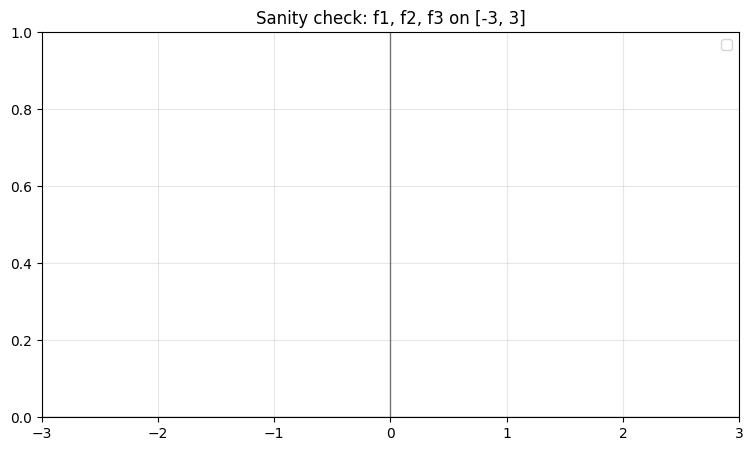

In [7]:
def f1(x):  # convex
    return x**2

def g1(x):
    return 2*x

def f2(x):  # non-convex
    return x**3 - 10*x**2

def g2(x):
    return 3*x**2 - 20*x

def f3(x):  # non-convex
    return x**4 - 10*x**2 - 2*x

def g3(x):
    return 4*x**3 - 20*x - 2


# TODO Quick sanity check: plot functions in interval -3,3
x = np.linspace(-3, 3, 400)

plt.figure(figsize=(9, 5))

plt.xlim(-3, 3)
plt.axhline(0, color="black", linewidth=1, alpha=0.5)
plt.axvline(0, color="black", linewidth=1, alpha=0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Sanity check: f1, f2, f3 on [-3, 3]")
plt.show()


### MODULE 1 — Task 1: Implement GD update (1D)

We implement GD that stores all iterates `x_k` in a list called `history`.
This will let us plot both the path on the function and iteration curves.
Keep it simple: fixed learning rate, fixed number of iterations.

**What do you observe?** (after running later)
- With small η: slow but stable movement.
- With a good η: faster convergence.
- With too-large η: oscillation or divergence.

**Expected takeaway:** Step size is a stability–speed tradeoff, and the “safe” range depends on the function curvature.


In [8]:
def gradient_descent(start, lr, iters, grad):
    """
    Fixed-step gradient descent in 1D.
    Returns:
      history: list of x_k values (length iters+1)
    """
    x = float(start)
    history = [x]

    for k in range(iters):
        pass
        # TODO: implement the GD update x <- x - lr * grad(x)
        # Append new point to history

    return history


# Quick smoke test
h_test = gradient_descent(start=5.0, lr=0.1, iters=10, grad=g1)
print("last iterate:", h_test[-1])


last iterate: 5.0


### MODULE 1 — Task 2: Plot f1(x)=x^2 with iterates for different learning rates

We’ll try 2–3 learning rates:
- **small** (slow but stable),
- **good** (fast, stable),
- **too large** (oscillates / diverges).

Use the same start and iterations so comparisons are fair.

**What do you observe?**
- Do iterates move monotonically toward 0?
- Does the path “bounce” across the minimum?

**Expected takeaway:** On a simple convex quadratic, GD behavior is easy to see: too-large η causes bouncing and may not decrease f.


In [9]:
start = 6.0
iters = 20
lrs = [0.05, 0.3, 1.1]  # small / good / too large (for x^2, lr>1 typically unstable)

xs_plot = (-8, 8)

for lr in lrs:
    pass
    # TODO: run experiment and plot f1(x) with iterates for lr



### MODULE 1 — Task 3: Plot iteration histories (x_k and f(x_k))

Iteration plots are a debugging superpower:
- `x_k vs k` shows oscillations or slow drift.
- `f(x_k) vs k` shows whether we actually decrease the objective.

**What do you observe?**
- Which lr decreases f fastest?
- For the unstable lr, does f explode?

**Expected takeaway:** Always plot `f(x_k)` when diagnosing optimization: the path might “look okay” but f might not decrease.


In [10]:
for lr in lrs:
    pass
    # TODO: run experiment and plot history for f1(x) with iterates for lr



### MODULE 1 — Task 4: Non-convex sensitivity (f2 or f3)

Non-convex objectives can have:
- multiple critical points (minima, maxima, saddles),
- basins of attraction that depend on start,
- more fragile stability ranges for η.

We will run GD on a non-convex function and compare:
1) different learning rates, and
2) different starting points.

**What do you observe?**
- Do you end up in different places for different starts?
- Does the “good” lr for convex f1 still look good here?

**Expected takeaway:** Non-convex GD is more sensitive: initialization + step size can change the outcome dramatically.


In [11]:
# Choose non-convex function: f2 or f3 make two ore more experiments (you can examinate other functions)
f_nc, g_nc, name = f3, g3, "f3(x)=x^4 - 10x^2 - 2x"
#TODO Create experiments with different starts, lrs, and iters then plot_1d_function_with_path



### MODULE 1 — Quick reflection (30–60 seconds)

**What do you observe?**
- On f1, what is the “too large” lr signature in `x_k` and `f(x_k)`?
- On f3, do two different starts converge to different regions/minima?

**Expected takeaway:** Always connect *plots* (trajectory + f(x_k)) to *diagnosis* (stable/unstable, slow/fast, basin dependence).


## MODULE 2 — Armijo backtracking line search (20 min)

Goal: instead of picking a fixed η by hand, we choose η adaptively each step.

**Armijo condition (informal):** choose η so that
$
f(x - \eta g) \le f(x) - c \eta \|g\|^2
$
In 1D, $\|g\|^2$ is just $g^2$.
If the condition fails, shrink $η ← β η$ and try again (backtracking).

We will:
1) implement `armijo_backtracking(...)` (1D),
2) implement GD that uses it, and
3) compare fixed-lr vs Armijo on a non-convex function.


### MODULE 2 — Task 1: Implement Armijo backtracking (1D)

We’ll implement a function that returns a step size η.
Inputs:
- f: objective
- x: current point
- g: gradient at x (a scalar in 1D)
- eta0: initial trial step size
- c: Armijo parameter (small, like 1e-4)
- beta: shrink factor (e.g., 0.5)
- max_steps: stop after some shrink attempts

**What do you observe?** (later)
- When gradients are large or curvature is harsh, η shrinks.
- When things are smooth, η can stay near eta0.

**Expected takeaway:** Line search automates stability: “if decrease is not sufficient, reduce step”.


In [12]:
def armijo_backtracking(f, x, g, eta0=1.0, c=1e-4, beta=0.5, max_steps=25):
    """
    1D Armijo backtracking.
    Returns:
      eta: accepted step size
      steps: number of backtracking reductions performed
    """
    eta = float(eta0)
    fx = float(f(x))

    # In 1D, directional step is x_new = x - eta * g
    # Armijo sufficient decrease: f(x_new) <= f(x) - c * eta * (g^2)

    steps = 0
    for j in range(max_steps):
        x_new = x - eta * g
        # TODO: implement the Armijo condition check
        # TODO: backtracking update eta *= beta if condition fails


    return eta, steps  # return the final (small) eta if max_steps reached


# Smoke test on f1 at x=10
eta, steps = armijo_backtracking(f2, x=10.0, g=g1(10.0), eta0=1.0)
print("eta:", eta, "backtracking steps:", steps)


eta: 1.0 backtracking steps: 0


### MODULE 2 — Task 2: GD with Armijo (track η_k)

We implement GD that calls Armijo each iteration and stores:
- `history`: x_k
- `eta_history`: η_k

This allows us to visualize:
- path on f(x),
- f(x_k) vs k,
- η_k vs k.

**What do you observe?**
- Does η shrink early then stabilize?
- Does Armijo prevent divergence compared to a fixed lr?

**Expected takeaway:** Adaptive step sizes can make GD robust when fixed lr is hard to tune.


In [13]:
def gd_with_armijo(start, iters, f, grad, eta0=1.0, c=1e-4, beta=0.5, max_steps=25):
    x = float(start)
    history = [x]
    eta_history = []

    for k in range(iters):
        g = float(grad(x))
        # TODO: GD update using the Armijo-chosen eta add new point to history.


    return history, eta_history


# Smoke test
hA, eA = gd_with_armijo(start=6.0, iters=20, f=f1, grad=g1, eta0=1.0)
print("last x:", hA[-1], "eta first/last:", eA[0], eA[-1])


last x: 6.0 eta first/last: 1.0 1.0


### MODULE 2 — Task 3: Compare fixed-lr GD vs Armijo on a non-convex objective

We’ll use the same start point for a fair comparison.
You should see that:
- fixed lr might be too aggressive (blow up) or too small (slow),
- Armijo adapts η_k to maintain sufficient decrease.

We’ll plot:
1) f(x) with iterates
2) f(x_k) vs k
3) η_k vs k (Armijo only)

**What do you observe?**
- Does Armijo reduce large steps in steep regions?
- Compared to fixed lr, is the objective curve more stable?

**Expected takeaway:** Armijo often “saves” you from instability with minimal manual tuning.


In [14]:
# Choose a non-convex function for comparison
f_cmp, g_cmp, name = f2, g2, "f2(x)=x^3 - 10x^2"
start = 17.1
iters = 50
xs_plot = (-2, 12)

# Fixed learning rates to compare
fixed_lrs = []

# Run fixed-lr GD
hist_fixed = {}


# Run Armijo GD


# Plot function + paths



# Plot objective histories


# Plot eta_k
plt.figure(figsize=(7, 3.5))
plt.plot(eta_hist, marker="o")
plt.title(f"{name} | Armijo step sizes η_k")
plt.xlabel("k")
plt.ylabel("η_k")
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'eta_hist' is not defined

<Figure size 700x350 with 0 Axes>

### MODULE 2 — Discussion

**What do you observe?**
- When does η_k shrink the most? (early iterations? near steep regions?)
- Does Armijo produce smoother f(x_k) decrease than fixed lr?
- Did fixed lr ever increase f(x_k) or diverge?

**Expected takeaway:**
Armijo is a practical “auto-tuner” that enforces sufficient decrease. It can be slower per-iteration (extra function calls),
but it reduces the risk of catastrophic step sizes when the landscape changes.


## MODULE 3 — Incorporate Numerical Methods for ODEs

We now add **momentum-based gradient descent**:

$$
v_{t+1} = \gamma v_t - \eta \nabla f(x_t), \qquad x_{t+1} = x_t + v_{t+1}
$$

where:
- $\eta$ is the learning rate,
- $\gamma \in [0,1)$ is the momentum coefficient,
- $v_t$ stores a running velocity.
We now add **momentum-based gradient descent**:

$$
v_{t+1} = \gamma v_t - \eta \nabla f(x_t), \qquad x_{t+1} = x_t + v_{t+1}
$$

where:
- $\eta$ is the learning rate,
- $\gamma \in [0,1)$ is the momentum coefficient,
- $v_t$ stores a running velocity.

This is closely related to the damped second-order ODE
$$
\ddot{x} + c\dot{x} + \nabla f(x) = 0.
$$
If we introduce velocity $v = \dot{x}$, then
$$
\dot{x} = v, \qquad \dot{v} = -c v - \nabla f(x).
$$
A forward-Euler style discretization with step size $h$ gives
$$
v_{k+1} \approx (1 - h c) v_k - h\nabla f(x_k), \qquad x_{k+1} \approx x_k + v_{k+1},
$$
so the discrete momentum parameter behaves like $\gamma \approx 1 - h c$.

**What should you observe?**
- Momentum can accelerate progress in shallow regions.
- It may also overshoot and oscillate near minima.
- Compared with plain GD, it behaves more like a particle with inertia and damping.

### MODULE 3 — Task 4: Incorporate Numerical Methods for ODEs




In [ ]:
def momentum_gradient_descent(start, lr, gamma, iters, grad):
    """
    1D momentum GD inspired by the Euler discretization of a damped ODE.
    Returns:
      history: x_k values
      velocity_history: v_k values
    """
    x = float(start)
    v = 0.0
    history = [x]
    velocity_history = [v]

    for k in range(iters):
        # TODO implement momentum update
        pass

    return history, velocity_history


# Quick smoke test
h_mom, v_mom = momentum_gradient_descent(start=6.0, lr=0.1, gamma=0.8, iters=10, grad=g1)
print("last x:", h_mom[-1], "last velocity:", v_mom[-1])


In [4]:
# Compare plain GD and momentum GD on the same non-convex objective
f_ode, g_ode, name_ode = f2, g2, "f2(x)=x^3 - 10x^2"
start = 17.1
iters = 35
xs_plot = (-2, 18)

lr_plain = 0.01
lr_momentum = 0.01
gamma = 0.85


# Run GD and Momentum


# Plot function + paths



# Plot objective histories


#Polot momentum velocity


print("plain GD last x:", hist_plain[-1], "last f(x):", f_ode(hist_plain[-1]))
print("momentum GD last x:", hist_momentum[-1], "last f(x):", f_ode(hist_momentum[-1]))


NameError: name 'f2' is not defined

## MODULE 4 — Stochastic Gradient Descent (SGD)


In [ ]:
# TODO prepare full SGD experiemntes based on the previous experiments

TO BE CONTINUED IN NEXT LAB